<div style="background:linear-gradient(135deg,#083344 0%,#0e7490 55%,#06b6d4 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a5f3fc;font-weight:700;text-transform:uppercase">Chapter 138 &#183; Extended Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: A Paired Pre/Post Study</div>
  <div style="font-size:15px;color:#cffafe;max-width:740px;line-height:1.6">Did a redesign make the checkout faster? Forty-five users timed the same task on the old and new design. Because each user is measured twice, a paired analysis uses every person as their own control, and it finds an effect that a between-groups comparison nearly misses.</div>
  <div style="margin-top:16px;font-size:13px;color:#a5f3fc">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 1 &#183; DEFINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The question, and why measure everyone twice</div>
<div style="color:#4a5578;margin-top:6px">A within-subject design is the most powerful way to detect a change.</div>
</div>

A team redesigned the checkout flow and wants to know: **is the new design faster to complete?** They could split users into two groups (one per design), but people vary enormously in how fast they work, and that variation would drown out the effect. Instead every user does the task on **both** designs, so each person serves as their own control. The analysis then works on **within-person differences**, and the star tests are the **paired t-test** and its distribution-free partner, the **Wilcoxon signed-rank test**.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 &#183; DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One row per user, two measurements</div>
<div style="color:#4a5578;margin-top:6px">The defining feature of a paired design: the pairing.</div>
</div>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
EM="#0891b2"; DEEP="#0e7490"; LIGHT="#a5f3fc"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; GREEN="#059669"; GREY="#94a3b8"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_excel("../../data/case-study-a-paired-pre-post-study--ux_redesign.xlsx", sheet_name="Data")
except FileNotFoundError: df = pd.read_excel(BASE+"case-study-a-paired-pre-post-study--ux_redesign.xlsx", sheet_name="Data")
print(f"users: {len(df)}   (each timed the same task on the OLD and NEW design)")
df.head(4)

users: 45   (each timed the same task on the OLD and NEW design)


,user_id,first_design,old_design_seconds,new_design_seconds
0,U01,old,73.5,74.5
1,U02,old,66.3,56.7
2,U03,new,65.4,52.1
3,U04,new,40.7,34.3


<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 3 &#183; EXPLORE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Look at the pairs, not just the groups</div>
<div style="color:#4a5578;margin-top:6px">A connected-line plot shows the change person by person.</div>
</div>

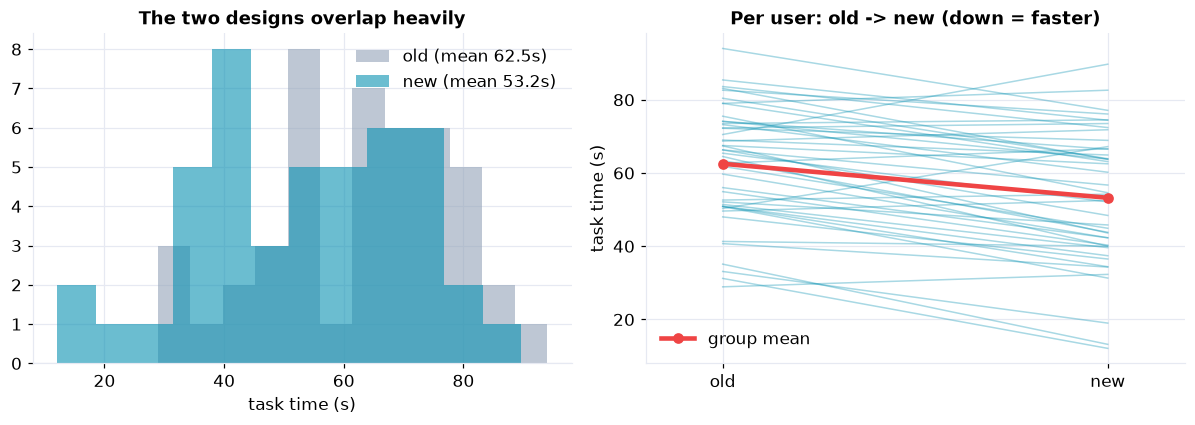

In [2]:
old, new = df.old_design_seconds, df.new_design_seconds
fig, ax = plt.subplots(1, 2, figsize=(11,4))
# left: the two distributions overlap a lot (big between-user spread)
ax[0].hist(old, bins=12, alpha=0.6, color=GREY, label=f"old (mean {old.mean():.1f}s)")
ax[0].hist(new, bins=12, alpha=0.6, color=EM, label=f"new (mean {new.mean():.1f}s)")
ax[0].set(title="The two designs overlap heavily", xlabel="task time (s)"); ax[0].legend()
# right: connect each user's two times -> almost every line slopes down
for _, r in df.iterrows():
    ax[1].plot([0,1], [r.old_design_seconds, r.new_design_seconds], color=EM, alpha=0.35, lw=1)
ax[1].plot([0,1], [old.mean(), new.mean()], color=RED, lw=3, marker="o", label="group mean")
ax[1].set(title="Per user: old -> new (down = faster)", xticks=[0,1], xlim=(-0.2,1.2), ylabel="task time (s)"); ax[1].set_xticklabels(["old","new"]); ax[1].legend()
plt.tight_layout(); plt.show()

The histograms on the left **overlap almost completely**, because users differ so much in baseline speed that the two designs look nearly the same in aggregate. But the connected lines on the right tell the real story: **person after person gets faster** on the new design. The pairing makes a consistent within-user improvement visible that the overlapping group distributions hide.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 4 &#183; THE PAIRING INSIGHT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Between-user variance is the enemy</div>
<div style="color:#4a5578;margin-top:6px">Pairing cancels it, leaving only the change you care about.</div>
</div>

In [3]:
between_user_sd = df[["old_design_seconds","new_design_seconds"]].mean(axis=1).std(ddof=1)
diff = new - old
print(f"spread BETWEEN users (avg speed)        : SD = {between_user_sd:.1f} s   <- huge, and irrelevant to the question")
print(f"spread of the within-user DIFFERENCES   : SD = {diff.std(ddof=1):.1f} s   <- what the paired test actually uses")
print("Pairing subtracts each user's own baseline, so the big between-user spread never enters the test.")

spread BETWEEN users (avg speed)        : SD = 16.3 s   <- huge, and irrelevant to the question
spread of the within-user DIFFERENCES   : SD = 10.1 s   <- what the paired test actually uses
Pairing subtracts each user's own baseline, so the big between-user spread never enters the test.


Users' average speeds vary with a standard deviation of about **16 seconds**, far bigger than the roughly 9-second effect we are hunting. A between-groups test has to see the signal through all that noise. The paired approach sidesteps it entirely by working on each user's **own** change, whose spread is much smaller. That is the whole reason to pair.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 5 &#183; THE DIFFERENCES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Compute them, and check their shape</div>
<div style="color:#4a5578;margin-top:6px">The paired test lives or dies on the difference distribution.</div>
</div>

mean difference (new - old) = -9.29 s   (negative = faster on the new design)
Shapiro-Wilk on the differences: W = 0.934, p = 0.013  -> NON-normal


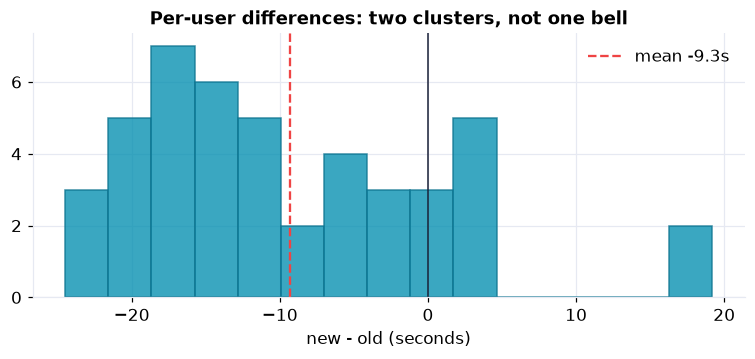

In [4]:
print(f"mean difference (new - old) = {diff.mean():+.2f} s   (negative = faster on the new design)")
sh = stats.shapiro(diff)
print(f"Shapiro-Wilk on the differences: W = {sh.statistic:.3f}, p = {sh.pvalue:.3f}  -> "
      + ("NON-normal" if sh.pvalue<0.05 else "roughly normal"))
fig, ax = plt.subplots(figsize=(7,3.4))
ax.hist(diff, bins=15, color=EM, alpha=0.8, edgecolor=DEEP)
ax.axvline(0, color=INK, lw=1); ax.axvline(diff.mean(), color=RED, ls="--", lw=1.5, label=f"mean {diff.mean():.1f}s")
ax.set(title="Per-user differences: two clusters, not one bell", xlabel="new - old (seconds)"); ax.legend()
plt.tight_layout(); plt.show()

The differences are **not a clean bell**: there is a big cluster of users who got much faster and a second cluster near zero who barely changed. Shapiro-Wilk confirms it (p = 0.01, non-normal). That matters, because the paired **t-test** assumes roughly normal differences. With a bimodal shape like this, the honest primary test is the distribution-free **Wilcoxon signed-rank**, and we report the t-test alongside as a familiar cross-check.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 6 &#183; THE PAIRED t-TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The classic test on the differences</div>
<div style="color:#4a5578;margin-top:6px">Valid when the differences are near-normal; here, an approximation.</div>
</div>

In [5]:
t = stats.ttest_rel(new, old)
# confidence interval for the mean difference (paired)
sd = diff.std(ddof=1); n = len(diff); se = sd/np.sqrt(n)
crit = stats.t.ppf(0.975, n-1); lo, hi = diff.mean()-crit*se, diff.mean()+crit*se
print(f"paired t-test: t({n-1}) = {t.statistic:.2f}, p = {t.pvalue:.2e}")
print(f"mean difference = {diff.mean():.2f} s   95% CI [{lo:.2f}, {hi:.2f}]")

paired t-test: t(44) = -6.17, p = 1.92e-07
mean difference = -9.29 s   95% CI [-12.33, -6.25]


The paired t-test is emphatic, **t(44) = -6.17, p about 2e-7**, with a 95% confidence interval on the mean difference that sits well below zero (roughly -12 to -6 seconds). Because the differences are non-normal we treat this as an approximation, but with 45 users the Central Limit Theorem keeps it reasonable, and it agrees with the robust test next.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 7 &#183; THE ROBUST TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Wilcoxon signed-rank</div>
<div style="color:#4a5578;margin-top:6px">The distribution-free primary test when differences are skewed.</div>
</div>

In [6]:
w = stats.wilcoxon(new, old)
print(f"Wilcoxon signed-rank: W = {w.statistic:.0f}, p = {w.pvalue:.2e}")
n_faster = int((diff < 0).sum()); n_slower = int((diff > 0).sum())
print(f"{n_faster} of {len(df)} users were faster on the new design, {n_slower} were slower.")
print("Same verdict as the t-test, but it makes no normality assumption -> the one to lead with here.")

Wilcoxon signed-rank: W = 116, p = 6.00e-06
35 of 45 users were faster on the new design, 10 were slower.
Same verdict as the t-test, but it makes no normality assumption -> the one to lead with here.


Wilcoxon ranks the absolute differences and asks whether the positives and negatives balance out. They do not: the improvements dominate (**p about 6e-6**), and it needs no bell-curve assumption. When a paired difference distribution is skewed or bimodal, this is the test to report first; that it matches the t-test here is reassurance, not luck.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 8 &#183; EFFECT SIZE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How big is the change</div>
<div style="color:#4a5578;margin-top:6px">Significance is not the same as magnitude.</div>
</div>

In [7]:
dz = diff.mean() / diff.std(ddof=1)                 # Cohen's dz for a paired design
print(f"mean improvement = {abs(diff.mean()):.1f} s faster  (about {abs(diff.mean())/old.mean()*100:.0f}% of the old time)")
print(f"Cohen's dz = {dz:.2f}  (paired effect size; |0.2| small, |0.5| medium, |0.8| large)")

mean improvement = 9.3 s faster  (about 15% of the old time)
Cohen's dz = -0.92  (paired effect size; |0.2| small, |0.5| medium, |0.8| large)


The new design saves about **9 seconds per checkout, roughly 15% of the old time**, and the paired effect size is **Cohen's dz about -0.9**, a large effect. Reporting the effect size beside the p-value keeps the finding honest: this is not just statistically detectable, it is big enough to matter to real users.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 9 &#183; WHY PAIRING WINS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What a between-groups test would have found</div>
<div style="color:#4a5578;margin-top:6px">The same data, analyzed the wrong way.</div>
</div>

In [8]:
# Pretend we had ignored the pairing and run an independent-samples t-test instead
ind = stats.ttest_ind(new, old)
print(f"PAIRED     t = {t.statistic:.2f}, p = {t.pvalue:.1e}   (uses each user as their own control)")
print(f"UNPAIRED   t = {ind.statistic:.2f}, p = {ind.pvalue:.3f}   (treats old and new as two independent groups)")
print(f"\nSame effect, but the paired t is {abs(t.statistic)/abs(ind.statistic):.1f}x larger: pairing removed the between-user noise.")

PAIRED     t = -6.17, p = 1.9e-07   (uses each user as their own control)
UNPAIRED   t = -2.59, p = 0.011   (treats old and new as two independent groups)

Same effect, but the paired t is 2.4x larger: pairing removed the between-user noise.


Analyze the very same numbers as two independent groups and the effect nearly vanishes: **t drops from -6.2 to -2.6** and the p-value climbs from 2e-7 to 0.01. Nothing about the effect changed; the unpaired test simply cannot see it through the between-user variance that pairing cancels. This is the case for within-subject designs in one comparison: when you can measure each subject twice, do, and analyze the pairs.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 10 &#183; WHAT THE AVERAGE HIDES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two kinds of user</div>
<div style="color:#4a5578;margin-top:6px">A bimodal difference is a story, not a nuisance.</div>
</div>

In [9]:
faster = diff[diff < -5]      # clear responders
flat   = diff[diff >= -5]     # little or no change
print(f"responders (>5s faster): {len(faster)} users, averaging {faster.mean():.1f} s faster")
print(f"non-responders         : {len(flat)} users, averaging {flat.mean():+.1f} s")
print("The overall -9s average blends a big improvement for most with almost none for a sizable minority.")

responders (>5s faster): 31 users, averaging -14.9 s faster
non-responders         : 14 users, averaging +3.1 s
The overall -9s average blends a big improvement for most with almost none for a sizable minority.


The two clusters in Step 5 are real groups: most users get a large speed-up, while a sizable minority barely change. The headline **-9 seconds** is an average of those two stories. Worth a follow-up: who are the non-responders, and is there a task or device where the redesign does not help? A paired study points you straight at that question, which a single group mean would have buried.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 11 &#183; CAVEATS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What could bias a within-subject study</div>
<div style="color:#4a5578;margin-top:6px">The pairing brings its own risks.</div>
</div>

Two matter here. **Order and carryover:** doing the task twice means practice; the second design could look better just because users learned the task. The study **counterbalanced** the order (about half saw each design first, recorded in `first_design`), and the Take It Further notebook checks that order did not drive the result. **Single task, single session:** one checkout task on one day is a narrow slice; a durable claim needs more tasks and users. Neither undermines the finding, but a careful report names them.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 12 &#183; COMMUNICATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One paragraph for the product team</div>
<div style="color:#4a5578;margin-top:6px">Plain English, decision-ready.</div>
</div>

**For the product team:** In a within-subject test, 45 users completed the checkout task about **9 seconds faster on the new design (roughly 15% quicker)**, a large and statistically strong improvement (Wilcoxon p about 6e-6; paired t p about 2e-7). Because each user tried both designs, the test controls for the big differences in how fast people work, and it detects an effect that a simple two-group comparison would have called only marginal. One nuance: the gain is concentrated in most users, while a sizable minority saw little change, worth investigating before a full rollout. We recommend shipping the new design and following up on the non-responders.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>